<a href="https://colab.research.google.com/github/Ali13fffff/bank-customer-churn-analysis/blob/main/_churn_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Churn_Modelling.csv to Churn_Modelling.csv


#Import Libraries

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder as LE
from xgboost import XGBClassifier as XG
from sklearn.model_selection import GridSearchCV, StratifiedKFold,RandomizedSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier

Load Data

In [ ]:
df=pd.read_csv("Churn_Modelling.csv")
print(df.info())
print(df.head())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1   

Cleaning Data

In [ ]:
print(df.isnull().sum())
print(df.duplicated().sum())
df=df.drop(columns=["RowNumber","CustomerId","Surname"])
print(df.info())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non

#Creating Engineered Features

In [ ]:


df["Age_Group"]=pd.cut(df["Age"],bins=[17,30,44,65,100],labels=["18-30","31-44","45-65","+66"])
df["salary_to_Balance"]=df["EstimatedSalary"]/(df["Balance"]+1)
df["Balance_to_Salary"]=df["Balance"]/(df["EstimatedSalary"]+1)
df["Balance_per_Age"]=df["Balance"]/(df["Age"])
df["Active_older"]=((df["IsActiveMember"]==0) & (df["Age"]>=45)).astype(int)

#Feature Engineering

In [ ]:


le = LE()
df['Gender'] = le.fit_transform(df['Gender'])

df = pd.get_dummies(df, columns=['Geography','Age_Group'], drop_first=True, dtype=int)

#Data Splitting

In [ ]:
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

#Hyperparameter Tuning (RandomizedSearchCV

In [ ]:


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_dist = {
    "max_depth": [3, 4, 5, 6, 8, 10,12],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 200, 300, 400,600],
'scale_pos_weight':[2,3,3.5,4]
}

random_search = RandomizedSearchCV(
    XG(random_state=42,),
    param_distributions=param_dist,
    n_iter=20,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)

print(f"Best params: {random_search.best_params_}")
print(f"Best F1 Score: {random_search.best_score_}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'scale_pos_weight': 3, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05}
Best F1 Score: 0.6183686910136356


#XGBoost Hyperparameter Tuning

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.92      0.87      0.89      1593
           1       0.57      0.70      0.63       407

    accuracy                           0.83      2000
   macro avg       0.75      0.78      0.76      2000
weighted avg       0.85      0.83      0.84      2000

ROC-AUC Score: 0.8683



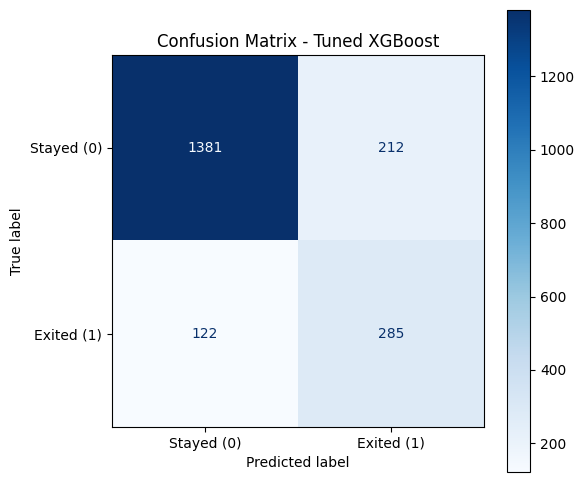

In [ ]:



best_model = random_search.best_estimator_


y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]


print("Classification Report on Test Set:")
print(classification_report(y_test, y_pred))


roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}\n")


cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stayed (0)", "Exited (1)"])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title("Confusion Matrix - Tuned XGBoost")
plt.grid(False)
plt.show()

#Feature Importance

Feature Importance:
              Feature  Importance
16    Age_Group_45-65    0.423372
12       Active_older    0.206083
5       NumOfProducts    0.073215
2                 Age    0.062856
13  Geography_Germany    0.047588
7      IsActiveMember    0.036283
4             Balance    0.025122
1              Gender    0.024780
10  Balance_to_Salary    0.022970
9   salary_to_Balance    0.021031
11    Balance_per_Age    0.012313
14    Geography_Spain    0.010508
0         CreditScore    0.008515
3              Tenure    0.008253
8     EstimatedSalary    0.006896
15    Age_Group_31-44    0.005289
6           HasCrCard    0.004925
17      Age_Group_+66    0.000000


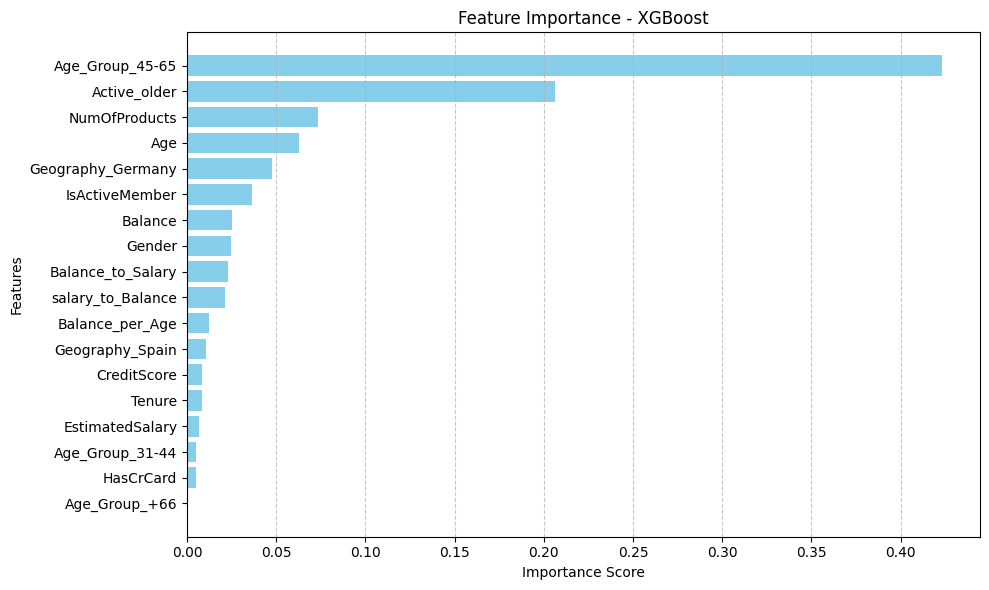

In [ ]:


importances = best_model.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importance:")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Random Forest Training, Evaluation, and Feature Importance

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params (RF): {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 10}
Best F1 Score (RF): 0.6196707724972574
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1593
           1       0.60      0.67      0.63       407

    accuracy                           0.84      2000
   macro avg       0.76      0.78      0.77      2000
weighted avg       0.85      0.84      0.84      2000

ROC-AUC: 0.8659


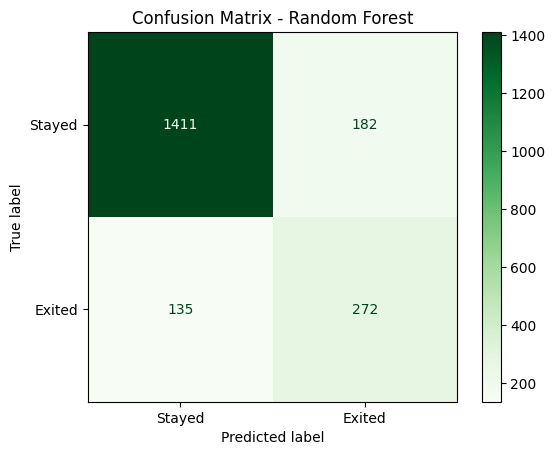

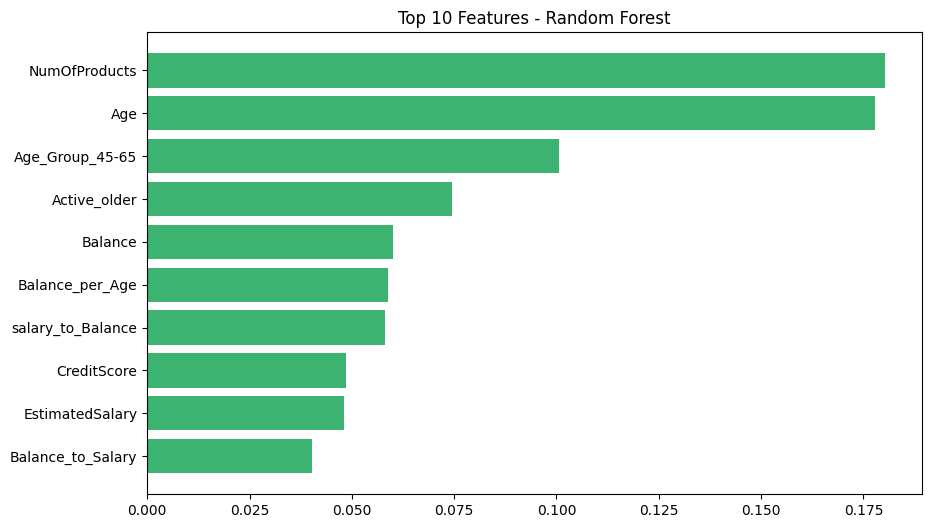

In [ ]:

rf_model = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)

param_dist_rf = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 8, 10,12],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

cv_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring="f1",
    cv=cv_rf,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rf_random_search.fit(X_train, y_train)

best_rf = rf_random_search.best_estimator_
print(f"Best Params (RF): {rf_random_search.best_params_}")
print(f"Best F1 Score (RF): {rf_random_search.best_score_}")

y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Stayed", "Exited"])
disp_rf.plot(cmap=plt.cm.Greens)
plt.title("Confusion Matrix - Random Forest")
plt.show()

importances_rf = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importances_rf["Feature"].head(10), importances_rf["Importance"].head(10), color="mediumseagreen")
plt.gca().invert_yaxis()
plt.title("Top 10 Features - Random Forest")
plt.show()

#Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

#KNN Hyperparameter Tuning and Evaluation

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params (KNN): {'weights': 'distance', 'p': 1, 'n_neighbors': 11, 'metric': 'minkowski'}
Best F1 Score (KNN): 0.4996807045130714
              precision    recall  f1-score   support

           0       0.86      0.96      0.90      1593
           1       0.69      0.37      0.48       407

    accuracy                           0.84      2000
   macro avg       0.77      0.66      0.69      2000
weighted avg       0.82      0.84      0.82      2000

ROC-AUC: 0.8046


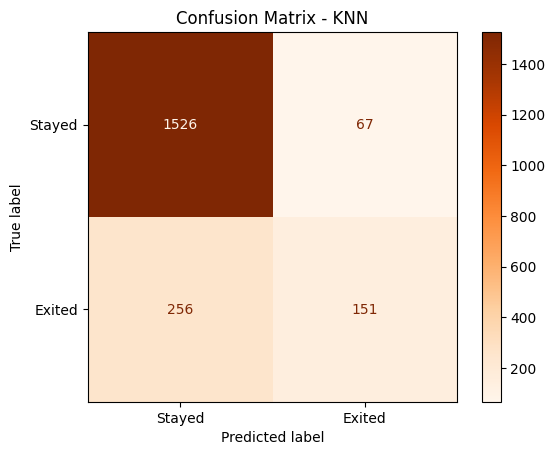

In [ ]:


knn_model = KNeighborsClassifier()

param_dist_knn = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"],
    "p": [1, 2]
}

cv_knn = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

knn_random_search = RandomizedSearchCV(
    estimator=knn_model,
    param_distributions=param_dist_knn,
    n_iter=20,
    scoring="f1",
    cv=cv_knn,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

knn_random_search.fit(X_train_scaler, y_train)

best_knn = knn_random_search.best_estimator_
print(f"Best Params (KNN): {knn_random_search.best_params_}")
print(f"Best F1 Score (KNN): {knn_random_search.best_score_}")

y_pred_knn = best_knn.predict(X_test_scaler)
y_pred_proba_knn = best_knn.predict_proba(X_test_scaler)[:, 1]

print(classification_report(y_test, y_pred_knn))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_knn):.4f}")

cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=["Stayed", "Exited"])
disp_knn.plot(cmap=plt.cm.Oranges)
plt.title("Confusion Matrix - KNN")
plt.show()

#Naive Bayes Training and Evaluation

Naive Bayes Model Results
              precision    recall  f1-score   support

           0       0.80      0.99      0.88      1593
           1       0.15      0.00      0.01       407

    accuracy                           0.79      2000
   macro avg       0.48      0.50      0.45      2000
weighted avg       0.67      0.79      0.71      2000

ROC-AUC: 0.7128


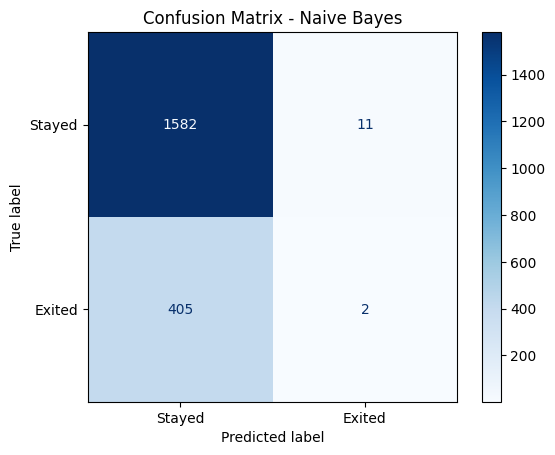

In [ ]:


nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)
y_pred_proba_nb = nb_model.predict_proba(X_test)[:, 1]

print("Naive Bayes Model Results")
print(classification_report(y_test, y_pred_nb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_nb):.4f}")

cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=["Stayed", "Exited"])
disp_nb.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

#SVM Hyperparameter Tuning

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params (SVM): {'kernel': 'rbf', 'gamma': 'scale', 'C': 1}
Best F1 Score (SVM): 0.591317065490262
              precision    recall  f1-score   support

           0       0.92      0.80      0.86      1593
           1       0.49      0.74      0.59       407

    accuracy                           0.79      2000
   macro avg       0.71      0.77      0.72      2000
weighted avg       0.83      0.79      0.80      2000

ROC-AUC: 0.8439


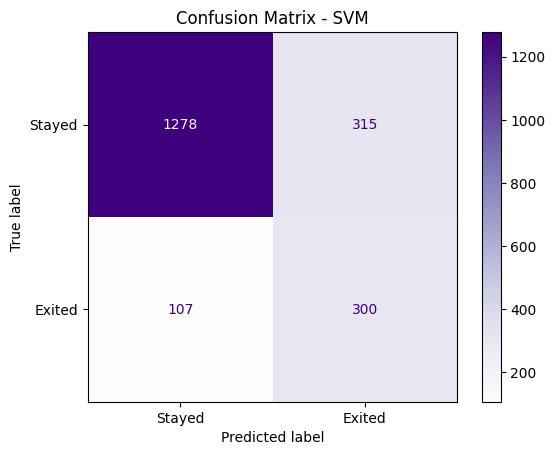

In [ ]:



svm_model = SVC(probability=True, class_weight="balanced", random_state=42)

param_dist_svm = {
    "C": [0.1, 1, 10, 50],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

cv_svm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm_random_search = RandomizedSearchCV(
    estimator=svm_model,
    param_distributions=param_dist_svm,
    n_iter=8,
    scoring="f1",
    cv=cv_svm,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

svm_random_search.fit(X_train_scaler, y_train)

best_svm = svm_random_search.best_estimator_
print(f"Best Params (SVM): {svm_random_search.best_params_}")
print(f"Best F1 Score (SVM): {svm_random_search.best_score_}")

y_pred_svm = best_svm.predict(X_test_scaler)
y_pred_proba_svm = best_svm.predict_proba(X_test_scaler)[:, 1]

print(classification_report(y_test, y_pred_svm))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_svm):.4f}")

cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=["Stayed", "Exited"])
disp_svm.plot(cmap=plt.cm.Purples)
plt.title("Confusion Matrix - SVM")
plt.show()

#Decision Tree Feature Importance

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Decision Tree Parameters:
{'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 10, 'criterion': 'gini', 'ccp_alpha': 0.001}

Best Cross-Validation F1 Score: 0.5691

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.81      0.87      1593
           1       0.50      0.75      0.60       407

    accuracy                           0.80      2000
   macro avg       0.72      0.78      0.73      2000
weighted avg       0.84      0.80      0.81      2000

ROC-AUC Score: 0.8516


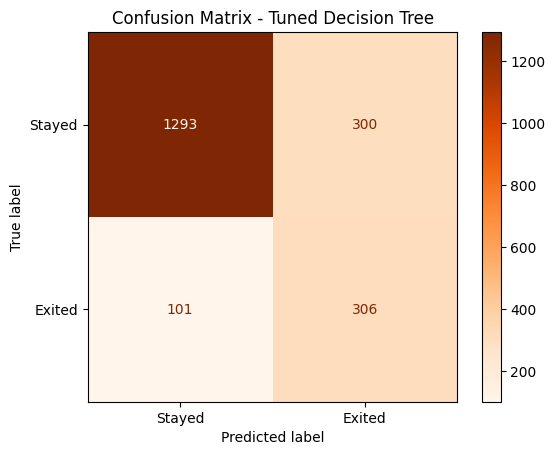

Top Feature Importances:
Age_Group_45-65      0.369225
NumOfProducts        0.324511
Balance_per_Age      0.062255
Geography_Germany    0.049095
Balance              0.048510
Active_older         0.041299
Age                  0.036062
salary_to_Balance    0.034347
IsActiveMember       0.015231
Age_Group_31-44      0.008503
EstimatedSalary      0.006047
HasCrCard            0.004915
Gender               0.000000
CreditScore          0.000000
Tenure               0.000000
dtype: float64


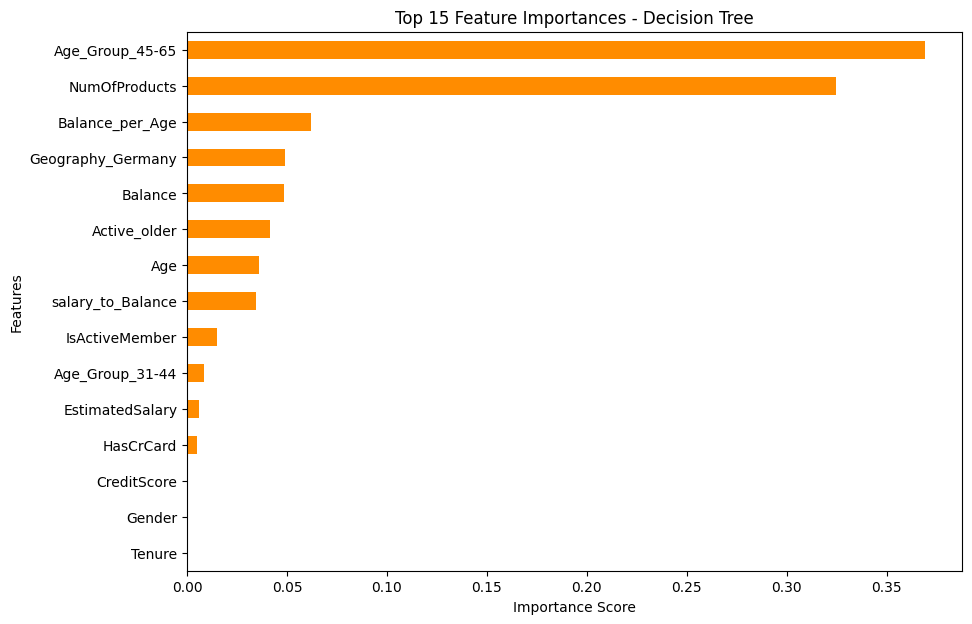

In [ ]:


dt_model = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

param_dist_dt = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [3, 5, 7, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20, 30],
    "min_samples_leaf": [1, 2, 4, 6, 10],
    "max_features": [None, "sqrt", "log2"],
    "ccp_alpha": [0.0, 0.0001, 0.001, 0.01]
}

cv_dt = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

dt_random_search = RandomizedSearchCV(
    estimator=dt_model,
    param_distributions=param_dist_dt,
    n_iter=30,
    scoring="f1",
    cv=cv_dt,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

dt_random_search.fit(X_train, y_train)

best_dt = dt_random_search.best_estimator_

y_pred_dt = best_dt.predict(X_test)
y_pred_proba_dt = best_dt.predict_proba(X_test)[:, 1]

print("Best Decision Tree Parameters:")
print(dt_random_search.best_params_)

print(f"\nBest Cross-Validation F1 Score: {dt_random_search.best_score_:.4f}")

print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_dt):.4f}")

cm_dt = confusion_matrix(y_test, y_pred_dt)

disp_dt = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["Stayed", "Exited"]
)

disp_dt.plot(cmap=plt.cm.Oranges)
plt.title("Confusion Matrix - Tuned Decision Tree")
plt.show()

importances_dt = pd.Series(
    best_dt.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)
print("Top Feature Importances:")
print(importances_dt.head(15))

plt.figure(figsize=(10, 7))
importances_dt.head(15).sort_values().plot(
    kind="barh",
    color="darkorange"
)
plt.title("Top 15 Feature Importances - Decision Tree")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()